Movie Recommendation System — ITAI 1371 Final Project
Author: Rich Fox | Instructor: Dr. Sina Nazifi | Spring 2026
 
Pipeline:
  1. Download & extract the MovieLens 32M dataset
  2. Exploratory Data Analysis (EDA)
  3. Feature Engineering
  4. Train KNN (collaborative filtering) and SVD (matrix factorization)
  5. Evaluate with RMSE, MAE, and Precision@K
  6. Item-based "movies like this" recommender
  7. User-based personalized recommender
  8. Save all artifacts to disk

# STEP 1 — Download & Extract

In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# 1. Load Movies (small file, usually fine)
df_movies = pd.read_csv('C:\Data\movies.csv')

# 2. Load and Filter Ratings in CHUNKS
# This prevents the 732MB+ allocation crash
chunks = []
# Only grab the columns we need to save space
cols = ['userId', 'movieId', 'rating']
dtype_dict = {'userId': np.int32, 'movieId': np.int32, 'rating': np.float32}

for chunk in pd.read_csv('C:\Data\\ratings.csv', usecols=cols, dtype=dtype_dict, chunksize=1000000):
    # Immediate Filter: drop movies with very few ratings if possible, 
    # but for now, just append the downcasted chunk
    chunks.append(chunk)

raw_ratings = pd.concat(chunks, axis=0)
del chunks # Free up memory immediately

# 3. Filter popular movies BEFORE merging or pivoting
movie_counts = raw_ratings.groupby('movieId')['rating'].count()
popular_movie_ids = movie_counts[movie_counts >= 50].index
raw_ratings = raw_ratings[raw_ratings['movieId'].isin(popular_movie_ids)]

# 4. Merge with titles ONLY for the filtered subset
pivot_data = pd.merge(raw_ratings, df_movies[['movieId', 'title']], on='movieId')

# 5. Create Sparse Matrix Directly (Avoids pivot_table)
pivot_data['title'] = pivot_data['title'].astype('category')
pivot_data['userId'] = pivot_data['userId'].astype('category')
user_means = pivot_data.groupby('userId')['rating'].transform('mean')
pivot_data['rating_norm'] = pivot_data['rating'] - user_means
movie_list = pivot_data['title'].cat.categories

sparse_matrix = csr_matrix((
    pivot_data['rating'].values, 
    (pivot_data['title'].cat.codes, pivot_data['userId'].cat.codes)
))

C:\Users\rfox\AppData\Local\Temp\ipykernel_28572\1145975252.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_means = pivot_data.groupby('userId')['rating'].transform('mean')


# STEP 2 - Exploratory Data Analysis (EDA) 

## Profiling the data

--- Basic Dataset Info ---
Total filtered ratings: 31498689
Unique Movies: 16028
Unique Users: 200947


C:\Users\rfox\AppData\Local\Temp\ipykernel_28572\3624231425.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pivot_data, x='rating', palette='viridis')


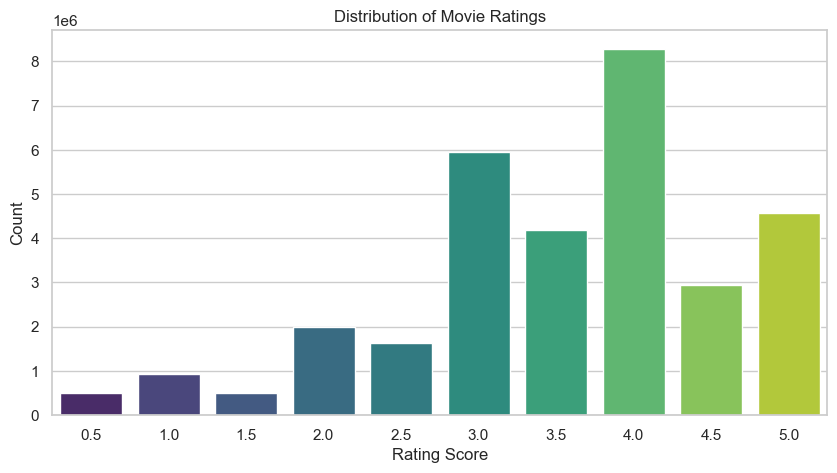

C:\Users\rfox\AppData\Local\Temp\ipykernel_28572\3624231425.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  movie_stats = pivot_data.groupby('title').agg({'rating': ['mean', 'count']})


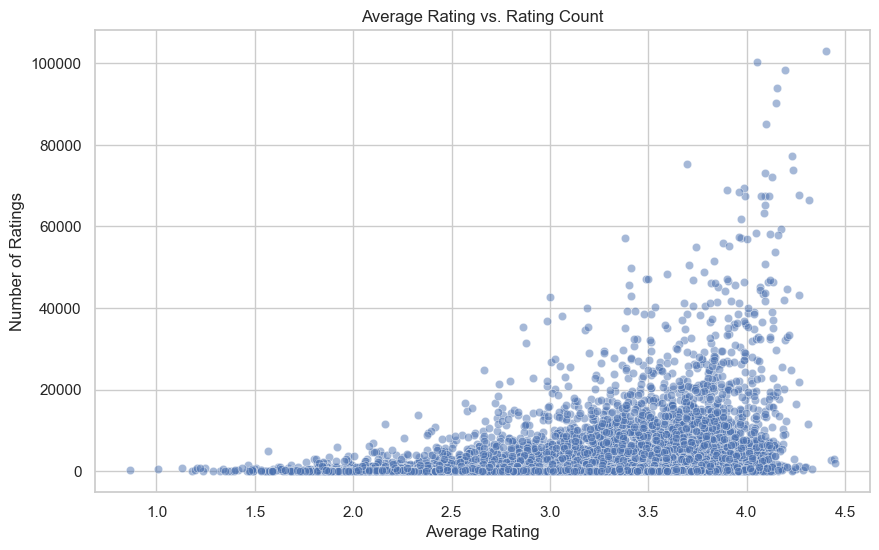

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

def perform_eda(pivot_data, df_movies):
    print("--- Basic Dataset Info ---")
    # 1. Shape and Nulls
    print(f"Total filtered ratings: {len(pivot_data)}")
    print(f"Unique Movies: {pivot_data['title'].nunique()}")
    print(f"Unique Users: {pivot_data['userId'].nunique()}")
    
    # 2. Rating Distribution (Histogram)
    plt.figure(figsize=(10, 5))
    sns.countplot(data=pivot_data, x='rating', palette='viridis')
    plt.title('Distribution of Movie Ratings')
    plt.xlabel('Rating Score')
    plt.ylabel('Count')
    plt.show()

    # 3. Top 10 Most Rated Movies
#    top_movies = pivot_data.groupby('title')['rating'].count().sort_values(ascending=False).head(10)
#    plt.figure(figsize=(12, 6))
#    sns.barplot(x=top_movies.values, y=top_movies.index, palette='magma')
#    plt.title('Top 10 Most Rated Movies (Popularity)')
#    plt.xlabel('Number of Ratings')
#    plt.show()

    # 4. Average Rating vs. Number of Ratings
    movie_stats = pivot_data.groupby('title').agg({'rating': ['mean', 'count']})
    movie_stats.columns = ['avg_rating', 'rating_count']
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=movie_stats, x='avg_rating', y='rating_count', alpha=0.5)
    plt.title('Average Rating vs. Rating Count')
    plt.xlabel('Average Rating')
    plt.ylabel('Number of Ratings')
    plt.show()

# Run the EDA
perform_eda(pivot_data, df_movies)


## Cleaning

In [3]:
# Not sure if its needed yet

# STEP 4 - Train KNN (collaborative filtering)


In [4]:
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(sparse_matrix)

def recommend_knn(movie_name, n_recommendations=5):
    if movie_name not in movie_list:
        print(f"'{movie_name}' not found.")
        return
    idx = movie_list.get_loc(movie_name)
    distances, indices = model_knn.kneighbors(sparse_matrix[idx], n_neighbors=n_recommendations+1)
    for i in range(1, len(distances.flatten())):
        print(f"{i}: {movie_list[indices.flatten()[i]]} (Similarity: {1 - distances.flatten()[i]:.2f})")

recommend_knn("Toy Story (1995)")

1: Toy Story 2 (1999) (Similarity: 0.57)
2: Star Wars: Episode IV - A New Hope (1977) (Similarity: 0.56)
3: Back to the Future (1985) (Similarity: 0.55)
4: Forrest Gump (1994) (Similarity: 0.54)
5: Jurassic Park (1993) (Similarity: 0.54)


# STEP 4.1 Train SVD

In [5]:
from scipy.sparse.linalg import svds
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. Double check: Is the sparse matrix (Movies x Users)?
# If shape is (Users, Movies), we need to transpose it:
if sparse_matrix.shape[0] > sparse_matrix.shape[1]:
    # Likely (Users, Movies), transpose to get (Movies, Users)
    input_matrix = sparse_matrix.T
else:
    input_matrix = sparse_matrix

# 2. Perform SVD
# We want 'u' to be the Movie Features
u, sigma, vt = svds(input_matrix, k=100)

# 3. u is now (Number of Movies, k)
# This is our feature set for movies
movie_features = u 

def recommend_svd(movie_name, n=5):
    if movie_name not in movie_list:
        print(f"'{movie_name}' not found.")
        return
    
    # Get the index
    idx = movie_list.get_loc(movie_name)
    
    # Extract the vector for the movie from 'u'
    movie_vector = movie_features[idx].reshape(1, -1)
    
    # Calculate similarity against all movies
    similarities = cosine_similarity(movie_vector, movie_features).flatten()
    
    # Get the top N indices (excluding itself)
    indices = np.argsort(similarities)[-(n+1):-1][::-1]
    
    for i, res_idx in enumerate(indices, 1):
        # res_idx will now be within the range of movie_list (0 to 16027)
        print(f"{i}: {movie_list[res_idx]} (Score: {similarities[res_idx]:.2f})")

recommend_svd("Toy Story (1995)")


1: Toy Story 2 (1999) (Score: 0.67)
2: Toy Story 3 (2010) (Score: 0.42)
3: Bug's Life, A (1998) (Score: 0.31)
4: Toy Story 4 (2019) (Score: 0.19)
5: James and the Giant Peach (1996) (Score: 0.18)


# STEP 5 — Evaluate: KNN, SVD, and Hybrid

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ── Train / Test Split ──────────────────────────────────────────────────────
train_data, test_data = train_test_split(pivot_data, test_size=0.2, random_state=42)

# ── Rebuild category codes aligned to the full pivot_data categories ─────────
user_list = pivot_data['userId'].cat.categories

# ── Training sparse matrix (Movies × Users) ──────────────────────────────────
train_matrix = csr_matrix((
    train_data['rating'].values,
    (train_data['title'].cat.codes, train_data['userId'].cat.codes)
), shape=(len(movie_list), len(user_list)))

print(f"Train samples: {len(train_data):,}  |  Test samples: {len(test_data):,}")
print(f"Train matrix shape: {train_matrix.shape}")


Train samples: 25,198,951  |  Test samples: 6,299,738
Train matrix shape: (16028, 200947)


In [7]:
# ── KNN Metrics ──────────────────────────────────────────────────────────────
knn_train = NearestNeighbors(metric='cosine', algorithm='brute')
knn_train.fit(train_matrix)

def evaluate_knn(test_df, k_prec=5, threshold=4.0):
    actuals, preds, precisions = [], [], []

    for user_id, group in test_df.groupby('userId'):
        try:
            u_idx = user_list.get_loc(user_id)
        except KeyError:
            continue

        user_preds = np.zeros(len(movie_list))
        for m_title, m_group in group.groupby('title'):
            try:
                m_idx = movie_list.get_loc(m_title)
            except KeyError:
                continue
            distances, indices = knn_train.kneighbors(
                train_matrix[m_idx], n_neighbors=11
            )
            neighbor_scores = []
            for dist, idx in zip(distances.flatten()[1:], indices.flatten()[1:]):
                sim = 1 - dist
                user_rating = train_matrix[idx, u_idx]
                if user_rating > 0:
                    neighbor_scores.append(sim * user_rating)
            if neighbor_scores:
                user_preds[m_idx] = np.sum(neighbor_scores) / len(neighbor_scores)
            else:
                user_preds[m_idx] = train_matrix[:, u_idx].data.mean() if train_matrix[:, u_idx].nnz > 0 else 3.5

        for _, row in group.iterrows():
            try:
                m_idx = movie_list.get_loc(row['title'])
                actuals.append(row['rating'])
                preds.append(user_preds[m_idx] if user_preds[m_idx] > 0 else 3.5)
            except KeyError:
                continue

        top_k_indices = np.argsort(user_preds)[-k_prec:]
        top_k_titles = set(movie_list[top_k_indices])
        actual_liked = set(group[group['rating'] >= threshold]['title'].values)
        precisions.append(len(top_k_titles & actual_liked) / k_prec)

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    print(f"📊 KNN Metrics (k={k_prec}):")
    print(f"  ✅ RMSE:           {rmse:.4f}")
    print(f"  ✅ MAE:            {mae:.4f}")
    print(f"  ✅ Precision@{k_prec}: {np.mean(precisions):.4f}")
    return rmse, mae, np.mean(precisions)

knn_rmse, knn_mae, knn_prec = evaluate_knn(test_data)


C:\Users\rfox\AppData\Local\Temp\ipykernel_28572\2683709401.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for user_id, group in test_df.groupby('userId'):
C:\Users\rfox\AppData\Local\Temp\ipykernel_28572\2683709401.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for m_title, m_group in group.groupby('title'):


KeyboardInterrupt: 

In [ ]:
# ── SVD Metrics ──────────────────────────────────────────────────────────────
u_t, sigma_t, vt_t = svds(train_matrix, k=50)
sigma_diag_t = np.diag(sigma_t)
predicted_ratings_svd = np.dot(np.dot(u_t, sigma_diag_t), vt_t)

def evaluate_svd(test_df, predicted_matrix, k_prec=5, threshold=4.0):
    actuals, preds, precisions = [], [], []

    for user_id, group in test_df.groupby('userId'):
        try:
            u_idx = user_list.get_loc(user_id)
        except KeyError:
            continue

        user_svd_preds = predicted_matrix[:, u_idx]

        for _, row in group.iterrows():
            try:
                m_idx = movie_list.get_loc(row['title'])
                actuals.append(row['rating'])
                preds.append(user_svd_preds[m_idx])
            except KeyError:
                continue

        top_k_indices = np.argsort(user_svd_preds)[-k_prec:]
        top_k_titles = set(movie_list[top_k_indices])
        actual_liked = set(group[group['rating'] >= threshold]['title'].values)
        precisions.append(len(top_k_titles & actual_liked) / k_prec)

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    print(f"📊 SVD Metrics (k={k_prec}):")
    print(f"  ✅ RMSE:           {rmse:.4f}")
    print(f"  ✅ MAE:            {mae:.4f}")
    print(f"  ✅ Precision@{k_prec}: {np.mean(precisions):.4f}")
    return rmse, mae, np.mean(precisions)

svd_rmse, svd_mae, svd_prec = evaluate_svd(test_data, predicted_ratings_svd)


In [ ]:
# ── Hybrid Metrics ───────────────────────────────────────────────────────────
# Uses the same get_knn_scores / get_svd_scores / get_genre_score helpers
# defined in STEP 7 below, but evaluated against the held-out test set.

def evaluate_hybrid(test_df, k_prec=5, threshold=4.0,
                    weights={'knn': 0.4, 'svd': 0.4, 'genre': 0.2}):
    actuals, preds, precisions = [], [], []

    for user_id, group in test_df.groupby('userId'):
        try:
            u_idx = user_list.get_loc(user_id)
        except KeyError:
            continue

        # Build a full-movie hybrid score vector for this user
        # by averaging hybrid similarity across movies the user rated in train
        user_train = train_data[train_data['userId'] == user_id]
        if user_train.empty:
            continue

        hybrid_scores = np.zeros(len(movie_list))
        weight_sum    = np.zeros(len(movie_list))

        for _, tr_row in user_train.iterrows():
            try:
                m_idx = movie_list.get_loc(tr_row['title'])
            except KeyError:
                continue

            knn_s = get_knn_scores(m_idx)
            svd_s = get_svd_scores(m_idx)
            candidates = set(knn_s) | set(svd_s)

            for cand_title in candidates:
                try:
                    c_idx = movie_list.get_loc(cand_title)
                except KeyError:
                    continue
                k = knn_s.get(cand_title, 0)
                s = svd_s.get(cand_title, 0)
                g = get_genre_score(tr_row['title'], cand_title)
                score = weights['knn']*k + weights['svd']*s + weights['genre']*g
                hybrid_scores[c_idx] += score * tr_row['rating']
                weight_sum[c_idx]    += tr_row['rating']

        with np.errstate(invalid='ignore', divide='ignore'):
            final_hybrid = np.where(weight_sum > 0, hybrid_scores / weight_sum, 0)

        for _, row in group.iterrows():
            try:
                m_idx = movie_list.get_loc(row['title'])
                actuals.append(row['rating'])
                preds.append(final_hybrid[m_idx] if final_hybrid[m_idx] > 0 else 3.5)
            except KeyError:
                continue

        top_k_indices = np.argsort(final_hybrid)[-k_prec:]
        top_k_titles  = set(movie_list[top_k_indices])
        actual_liked  = set(group[group['rating'] >= threshold]['title'].values)
        precisions.append(len(top_k_titles & actual_liked) / k_prec)

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    print(f"📊 Hybrid Metrics (k={k_prec}):")
    print(f"  ✅ RMSE:           {rmse:.4f}")
    print(f"  ✅ MAE:            {mae:.4f}")
    print(f"  ✅ Precision@{k_prec}: {np.mean(precisions):.4f}")
    return rmse, mae, np.mean(precisions)

hyb_rmse, hyb_mae, hyb_prec = evaluate_hybrid(test_data)


In [ ]:
# ── Side-by-Side Comparison ──────────────────────────────────────────────────
import pandas as pd

results = pd.DataFrame({
    'Model':        ['KNN Only', 'SVD Only', 'Hybrid'],
    'RMSE':         [knn_rmse,  svd_rmse,  hyb_rmse],
    'MAE':          [knn_mae,   svd_mae,   hyb_mae],
    'Precision@5':  [knn_prec,  svd_prec,  hyb_prec],
}).set_index('Model')

print("\n📋 Model Comparison Summary")
print(results.to_string(float_format='{:.4f}'.format))

best_rmse = results['RMSE'].min()
best_model = results['RMSE'].idxmin()
improvement = ((results.loc['KNN Only', 'RMSE'] if results.loc['KNN Only', 'RMSE'] < results.loc['SVD Only', 'RMSE']
                else results.loc['SVD Only', 'RMSE']) - hyb_rmse) /               min(results.loc['KNN Only', 'RMSE'], results.loc['SVD Only', 'RMSE']) * 100

print(f"\n🏆 Best model by RMSE: {best_model}")
print(f"🚀 Hybrid improvement over best individual: {improvement:.2f}%")


# STEP 6 — Hybrid Recommender

In [ ]:

def get_knn_scores(movie_idx):
    # Returns {Title: SimilarityScore}
    distances, indices = model_knn.kneighbors(sparse_matrix[movie_idx], n_neighbors=50)
    return {movie_list[i]: (1 - d) for i, d in zip(indices.flatten(), distances.flatten())}

def get_svd_scores(movie_idx):
    # Returns {Title: SimilarityScore}
    movie_vector = movie_features[movie_idx].reshape(1, -1)
    similarities = cosine_similarity(movie_vector, movie_features).flatten()
    return {movie_list[i]: s for i, s in enumerate(similarities)}

# 1. Ensure the genre lookup exists (run this once)
# If your movie dataframe is named 'df_movies', use that name here
genre_lookup = df_movies.set_index('title')['genres'].to_dict()

def get_genre_score(movie_a_name, movie_b_name):
    # Get genre strings from our dictionary
    str_a = genre_lookup.get(movie_a_name, "")
    str_b = genre_lookup.get(movie_b_name, "")
    
    set_a = set(str_a.split('|'))
    set_b = set(str_b.split('|'))
    
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union > 0 else 0

def recommend_hybrid_with_genres(movie_name, n=5, weights={'knn': 0.4, 'svd': 0.4, 'genre': 0.2}):
    if movie_name not in movie_list:
        print(f"'{movie_name}' not found in the dataset.")
        return
    
    # Get the index for model lookups
    target_idx = movie_list.get_loc(movie_name)

    # 2. Get scores from our individual models
    knn_results = get_knn_scores(target_idx) 
    svd_results = get_svd_scores(target_idx) 
    
    combined = []
    # Combine unique titles from both model results
    candidates = set(knn_results.keys()) | set(svd_results.keys())

    for title in candidates:
        if title == movie_name: continue
        
        # Pull scores (default to 0 if not found)
        k_score = knn_results.get(title, 0)
        s_score = svd_results.get(title, 0)
        
        # GET GENRE SCORE BY TITLE (No 'df' needed here!)
        g_score = get_genre_score(movie_name, title)
        
        # Calculate weighted average
        final_score = (k_score * weights['knn']) + \
                      (s_score * weights['svd']) + \
                      (g_score * weights['genre'])
        
        combined.append((title, final_score))

    # 3. Sort by the highest score
    combined.sort(key=lambda x: x[1], reverse=True)
    
    print(f"Final Hybrid Results for '{movie_name}':")
    for i, (title, score) in enumerate(combined[:n], 1):
        print(f"{i}: {title} (Score: {score:.2f})")

# Run the test
recommend_hybrid_with_genres("Toy Story (1995)")
print("")
recommend_hybrid_with_genres("Shrek (2001)")
print("")
recommend_hybrid_with_genres("The Lord of the Rings: The Fellowship of the Ring (2001)")
print("")
recommend_hybrid_with_genres("Dracula: Dead and Loving It (1995)")
print("")
recommend_hybrid_with_genres("The Matrix (1999)")

Final Hybrid Results for 'Toy Story (1995)':
1: Toy Story 2 (1999) (Score: 0.70)
2: Bug's Life, A (1998) (Score: 0.47)
3: Monsters, Inc. (2001) (Score: 0.46)
4: Aladdin (1992) (Score: 0.43)
5: Shrek (2001) (Score: 0.38)

Final Hybrid Results for 'Shrek (2001)':
1: Monsters, Inc. (2001) (Score: 0.76)
2: Finding Nemo (2003) (Score: 0.68)
3: Shrek 2 (2004) (Score: 0.65)
4: Incredibles, The (2004) (Score: 0.54)
5: Ice Age (2002) (Score: 0.52)

'The Lord of the Rings: The Fellowship of the Ring (2001)' not found in the dataset.

Final Hybrid Results for 'Dracula: Dead and Loving It (1995)':
1: Spy Hard (1996) (Score: 0.57)
2: Tales from the Crypt Presents: Bordello of Blood (1996) (Score: 0.56)
3: Sgt. Bilko (1996) (Score: 0.53)
4: Down Periscope (1996) (Score: 0.53)
5: Bio-Dome (1996) (Score: 0.50)

'The Matrix (1999)' not found in the dataset.
